In [ ]:
import os
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

%matplotlib inline
 
# Path to dataset folder
DATASET_PATH = os.path.join(".", "UCI HAR Dataset")

print("Dataset folder exists:", os.path.isdir(DATASET_PATH))

Dataset folder exists: True


In [3]:
# Load feature names
features_path = os.path.join(DATASET_PATH, "features.txt")
features = pd.read_csv(features_path, sep=r"\s+", header=None, names=["index", "feature_name"])
feature_names = features["feature_name"].values

print("Number of features:", len(feature_names))
print("First 10 features:", feature_names[:10])

# Load activity labels
activity_labels_path = os.path.join(DATASET_PATH, "activity_labels.txt")
activity_labels = pd.read_csv(activity_labels_path, sep=r"\s+", header=None, names=["id", "activity"])

print("\nActivity labels:")
activity_labels


Number of features: 561
First 10 features: ['tBodyAcc-mean()-X' 'tBodyAcc-mean()-Y' 'tBodyAcc-mean()-Z'
 'tBodyAcc-std()-X' 'tBodyAcc-std()-Y' 'tBodyAcc-std()-Z'
 'tBodyAcc-mad()-X' 'tBodyAcc-mad()-Y' 'tBodyAcc-mad()-Z'
 'tBodyAcc-max()-X']

Activity labels:


,id,activity
0,1,WALKING
1,2,WALKING_UPSTAIRS
2,3,WALKING_DOWNSTAIRS
3,4,SITTING
4,5,STANDING
5,6,LAYING


In [5]:
# Train paths
X_train_path = os.path.join(DATASET_PATH, "train", "X_train.txt")
y_train_path = os.path.join(DATASET_PATH, "train", "y_train.txt")
subject_train_path = os.path.join(DATASET_PATH, "train", "subject_train.txt")

# Test paths
X_test_path = os.path.join(DATASET_PATH, "test", "X_test.txt")
y_test_path = os.path.join(DATASET_PATH, "test", "y_test.txt")
subject_test_path = os.path.join(DATASET_PATH, "test", "subject_test.txt")

# 1) Load WITHOUT column names (header=None)
X_train = pd.read_csv(X_train_path, delim_whitespace=True, header=None)
y_train = pd.read_csv(y_train_path, delim_whitespace=True, header=None, names=["activity_id"])
subject_train = pd.read_csv(subject_train_path, delim_whitespace=True, header=None, names=["subject"])

X_test = pd.read_csv(X_test_path, delim_whitespace=True, header=None)
y_test = pd.read_csv(y_test_path, delim_whitespace=True, header=None, names=["activity_id"])
subject_test = pd.read_csv(subject_test_path, delim_whitespace=True, header=None, names=["subject"])

# 2) Now assign the feature names as columns
X_train.columns = feature_names
X_test.columns = feature_names

print("Train X:", X_train.shape)
print("Train y:", y_train.shape)
print("Test X:", X_test.shape)
print("Test y:", y_test.shape)


C:\Users\Ali Computers\AppData\Local\Temp\ipykernel_19984\3670377686.py:12: FutureWarning: The 'delim_whitespace' keyword in pd.read_csv is deprecated and will be removed in a future version. Use ``sep='\s+'`` instead
  X_train = pd.read_csv(X_train_path, delim_whitespace=True, header=None)
C:\Users\Ali Computers\AppData\Local\Temp\ipykernel_19984\3670377686.py:13: FutureWarning: The 'delim_whitespace' keyword in pd.read_csv is deprecated and will be removed in a future version. Use ``sep='\s+'`` instead
  y_train = pd.read_csv(y_train_path, delim_whitespace=True, header=None, names=["activity_id"])
C:\Users\Ali Computers\AppData\Local\Temp\ipykernel_19984\3670377686.py:14: FutureWarning: The 'delim_whitespace' keyword in pd.read_csv is deprecated and will be removed in a future version. Use ``sep='\s+'`` instead
  subject_train = pd.read_csv(subject_train_path, delim_whitespace=True, header=None, names=["subject"])
C:\Users\Ali Computers\AppData\Local\Temp\ipykernel_19984\3670377686.p

Train X: (7352, 561)
Train y: (7352, 1)
Test X: (2947, 561)
Test y: (2947, 1)


C:\Users\Ali Computers\AppData\Local\Temp\ipykernel_19984\3670377686.py:17: FutureWarning: The 'delim_whitespace' keyword in pd.read_csv is deprecated and will be removed in a future version. Use ``sep='\s+'`` instead
  y_test = pd.read_csv(y_test_path, delim_whitespace=True, header=None, names=["activity_id"])
C:\Users\Ali Computers\AppData\Local\Temp\ipykernel_19984\3670377686.py:18: FutureWarning: The 'delim_whitespace' keyword in pd.read_csv is deprecated and will be removed in a future version. Use ``sep='\s+'`` instead
  subject_test = pd.read_csv(subject_test_path, delim_whitespace=True, header=None, names=["subject"])


In [6]:
# Combine subject + activity + features for train and test
train_df = pd.concat([subject_train, y_train, X_train], axis=1)
test_df = pd.concat([subject_test, y_test, X_test], axis=1)

# Merge train and test
full_df = pd.concat([train_df, test_df], axis=0).reset_index(drop=True)

print("Full dataset shape:", full_df.shape)
full_df.head()


Full dataset shape: (10299, 563)


,subject,activity_id,tBodyAcc-mean()-X,tBodyAcc-mean()-Y,tBodyAcc-mean()-Z,tBodyAcc-std()-X,tBodyAcc-std()-Y,tBodyAcc-std()-Z,tBodyAcc-mad()-X,tBodyAcc-mad()-Y,...,fBodyBodyGyroJerkMag-meanFreq(),fBodyBodyGyroJerkMag-skewness(),fBodyBodyGyroJerkMag-kurtosis(),"angle(tBodyAccMean,gravity)","angle(tBodyAccJerkMean),gravityMean)","angle(tBodyGyroMean,gravityMean)","angle(tBodyGyroJerkMean,gravityMean)","angle(X,gravityMean)","angle(Y,gravityMean)","angle(Z,gravityMean)"
0,1,5,0.288585,-0.020294,-0.132905,-0.995279,-0.983111,-0.913526,-0.995112,-0.983185,...,-0.074323,-0.298676,-0.710304,-0.112754,0.030400,-0.464761,-0.018446,-0.841247,0.179941,-0.058627
1,1,5,0.278419,-0.016411,-0.123520,-0.998245,-0.975300,-0.960322,-0.998807,-0.974914,...,0.158075,-0.595051,-0.861499,0.053477,-0.007435,-0.732626,0.703511,-0.844788,0.180289,-0.054317
2,1,5,0.279653,-0.019467,-0.113462,-0.995380,-0.967187,-0.978944,-0.996520,-0.963668,...,0.414503,-0.390748,-0.760104,-0.118559,0.177899,0.100699,0.808529,-0.848933,0.180637,-0.049118
3,1,5,0.279174,-0.026201,-0.123283,-0.996091,-0.983403,-0.990675,-0.997099,-0.982750,...,0.404573,-0.117290,-0.482845,-0.036788,-0.012892,0.640011,-0.485366,-0.848649,0.181935,-0.047663
4,1,5,0.276629,-0.016570,-0.115362,-0.998139,-0.980817,-0.990482,-0.998321,-0.979672,...,0.087753,-0.351471,-0.699205,0.123320,0.122542,0.693578,-0.615971,-0.847865,0.185151,-0.043892


activity
LAYING                1944
STANDING              1906
SITTING               1777
WALKING               1722
WALKING_UPSTAIRS      1544
WALKING_DOWNSTAIRS    1406
Name: count, dtype: int64


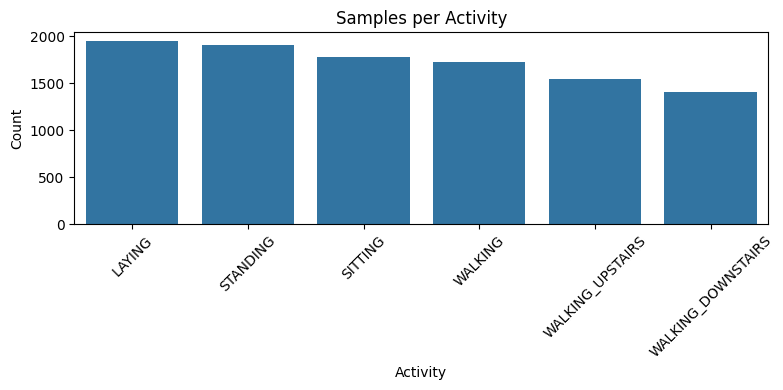

In [7]:
# Map activity_id to readable activity names
activity_map = dict(zip(activity_labels["id"], activity_labels["activity"]))
full_df["activity"] = full_df["activity_id"].map(activity_map)

# Count samples per activity
activity_counts = full_df["activity"].value_counts()
print(activity_counts)

plt.figure(figsize=(8,4))
sns.barplot(x=activity_counts.index, y=activity_counts.values)
plt.xticks(rotation=45)
plt.title("Samples per Activity")
plt.xlabel("Activity")
plt.ylabel("Count")
plt.tight_layout()
plt.show()


In [9]:
# X = all numeric sensor features
X = full_df[feature_names]

# y = activity label (text)
y = full_df["activity"]

print("X shape:", X.shape)
print("y shape:", y.shape)


X shape: (10299, 813)
y shape: (10299,)


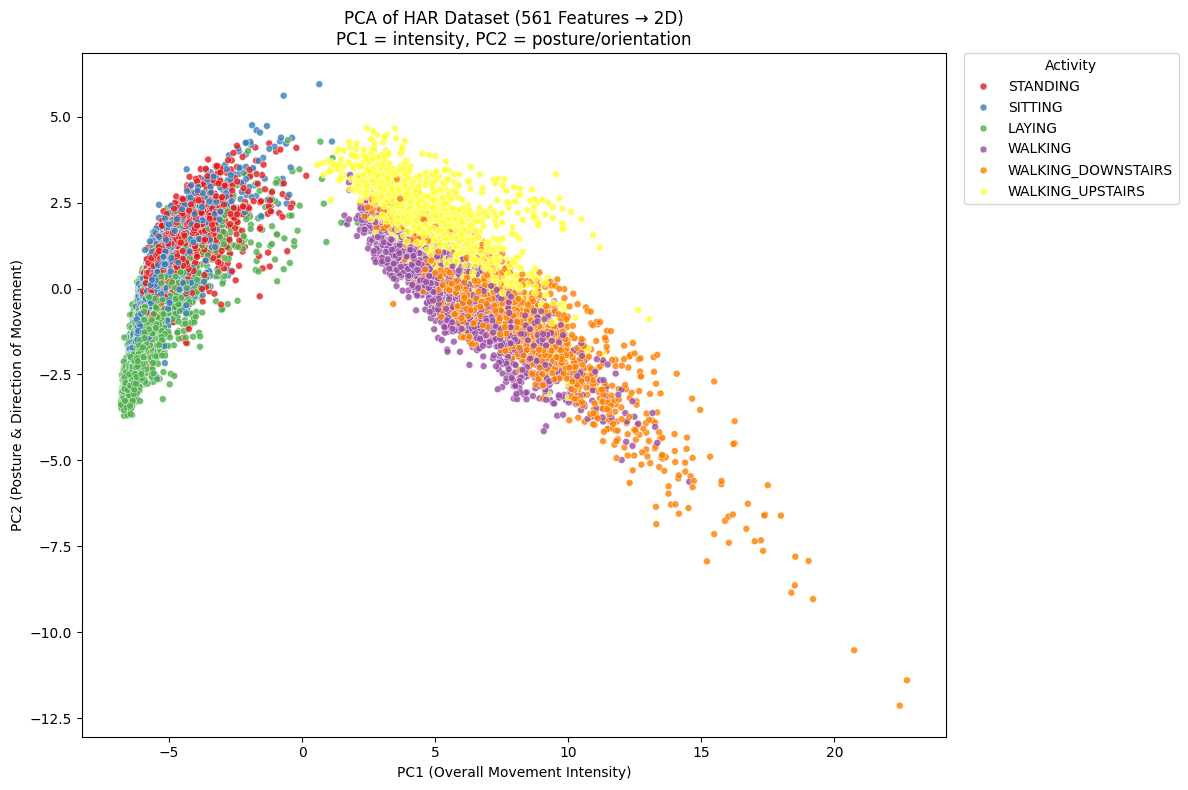

In [12]:
from sklearn.decomposition import PCA

# Compute PCA
pca = PCA(n_components=2)
X_pca = pca.fit_transform(X)

pca_df = pd.DataFrame({
    "PC1": X_pca[:, 0],
    "PC2": X_pca[:, 1],
    "activity": y
})

plt.figure(figsize=(12,8))
sns.scatterplot(
    data=pca_df,
    x="PC1",
    y="PC2",
    hue="activity",
    palette="Set1",
    s=25,
    alpha=0.8
)

# Better labels
plt.xlabel("PC1 (Overall Movement Intensity)")
plt.ylabel("PC2 (Posture & Direction of Movement)")
plt.title("PCA of HAR Dataset (561 Features → 2D)\nPC1 = intensity, PC2 = posture/orientation")

# Cleaner legend
plt.legend(
    title="Activity",
    bbox_to_anchor=(1.02, 1),
    loc="upper left",
    borderaxespad=0
)

plt.tight_layout()
plt.show()
